# RECAP - Open this notebook with Google Colab ;)

In [1]:
import os, sys
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

# 1. Load data from the Wine review Kaggle challenge

### Download csv (using Kaggle API for instance)

In [2]:
!pip install kaggle --quiet

Then, go to your Kaggle account and create a "New API TOKEN". It will launch the download of a file that you can store on your computer. Now, you have to load this file with the following command:

In [ ]:
# from google.colab import files
# files.upload();

ModuleNotFoundError: No module named 'google.colab'

Once this is done, just run:

In [ ]:
!mkdir -p ~/.kaggle
!cp "kaggle.json" ~/.kaggle/kaggle.json
# Give read & write rights
!chmod 600 ~/.kaggle/kaggle.json

You can now download the dataset thanks to:

In [ ]:
!kaggle datasets download -d zynicide/wine-reviews

Dataset URL: https://www.kaggle.com/datasets/zynicide/wine-reviews
License(s): CC-BY-NC-SA-4.0
 69% 35.0M/50.9M [00:00<00:00, 129MB/s] 
100% 50.9M/50.9M [00:00<00:00, 146MB/s]


We can now unzip the files

In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('wine-reviews.zip', 'r')
zip_ref.extractall('files')
zip_ref.close()

Let's check the files that you have downloaded:

In [ ]:
!ls files

winemag-data-130k-v2.csv  winemag-data-130k-v2.json  winemag-data_first150k.csv


### Load in RAM

In [ ]:
import pandas as pd
import os

data_path = 'files'
df = pd.read_csv(os.path.join(data_path, 'winemag-data-130k-v2.csv'), index_col=0)

In [ ]:
print(df.shape)
df.head(3)

(129971, 13)


,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm


Each row of the dataset corresponds to a wine description. Let's check out what is in the data, in particular the different columns as:
- the price of the wine bottle
- its description
- the number of "points" it has (on a scale from 0 to 100)

The goal here is not to do any data engineering. So let's take care of the missing values by removing the corresponding rows

In [ ]:
df = df.dropna()
df.shape

(22387, 13)

# 2. Predict Wine Price from Bottle Description

### Create X,y

Create our training set

In [ ]:
X_text = df['description'].values
y = df['price'].values

Let's split it into words

In [ ]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence
X_words = [text_to_word_sequence(sentence) for sentence in X_text]
X_words[0]

['much',
 'like',
 'the',
 'regular',
 'bottling',
 'from',
 '2012',
 'this',
 'comes',
 'across',
 'as',
 'rather',
 'rough',
 'and',
 'tannic',
 'with',
 'rustic',
 'earthy',
 'herbal',
 'characteristics',
 'nonetheless',
 'if',
 'you',
 'think',
 'of',
 'it',
 'as',
 'a',
 'pleasantly',
 'unfussy',
 'country',
 'wine',
 "it's",
 'a',
 'good',
 'companion',
 'to',
 'a',
 'hearty',
 'winter',
 'stew']

Another step is to convert your words into tokens as this is what the computer will work with.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tk = Tokenizer()
tk.fit_on_texts(X_words)
X_tokens = tk.texts_to_sequences(X_text)

# Vocab size?
vocab_size = len(tk.word_index)
vocab_size

16075

Now, we need to **pad the data**. Let's first check `sentence_length`

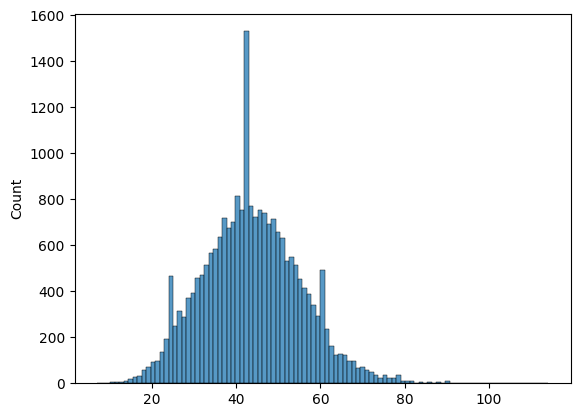

In [ ]:
import seaborn as sns
sns.histplot([len(x) for x in X_tokens]);

In [ ]:
# Choose max_length_padding
maxlen = 60

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_pad = pad_sequences(X_tokens, dtype=float, padding='post', maxlen=maxlen)
X_pad.shape

(22387, 60)

### NLP model

In [ ]:
# Baseline MAE score, when always predicting the mean price
y_mean = y.mean()
mae_baseline = np.mean(np.abs(y - y_mean))
print("MAE Baseline:", f"{mae_baseline:.2f}$")

MAE Baseline: 17.73$


Let's first build a NLP model. We'll use the functional API this time. Not just for fun. Later on you'll see why.

In [ ]:
# Embedding size?
embedding_size = 40

In [ ]:
from tensorflow.keras import Model, Input, layers
from tensorflow.keras.optimizers import Adam

# Define the model inputs, layers and outputs
inputs_nlp = Input(shape=(maxlen,))
x = layers.Embedding(input_dim=vocab_size+1, output_dim=embedding_size, mask_zero=True)(inputs_nlp)
x = layers.Conv1D(10, kernel_size=15, padding='same', activation="relu")(x)
x = layers.Conv1D(10, kernel_size=10, padding='same', activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dense(30, activation='relu')(x)
x = layers.Dropout(0.15)(x)
outputs_nlp = layers.Dense(1, activation='relu')(x)

# Define the model
model_nlp = Model(inputs=inputs_nlp, outputs=outputs_nlp)

model_nlp.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 60)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 60, 40)              │         643,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 60, 10)              │           6,010 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 60, 10)              │           1,010 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 600)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 30)                  │          18,030 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              31 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 668,121 (2.55 MB)

 Trainable params: 668,121 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

### Welcome TensorBoard 😎!
This is an amazing tool to see how the Neural Network trains

In [ ]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

# Clear any logs from previous runs
!rm -rf ./logs/

# We will store the logs in a folder (one folder per fit)
import datetime
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

Now, the logs of our fit will be given to a specifically designed folder that stores some of the information that TensorBoard needs

In [ ]:
from tensorflow.keras.callbacks import TensorBoard
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(patience=2)

model_nlp.compile(loss="mse", optimizer=Adam(learning_rate=1e-4), metrics=['mae'])

model_nlp.fit(X_pad, y,
          validation_split=0.3,
          epochs=50,
          batch_size=32,
          callbacks=[es, tensorboard_callback]
          )

Epoch 1/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - loss: 1708.8007 - mae: 30.9677 - val_loss: 1206.8540 - val_mae: 16.2388
Epoch 2/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - loss: 584.2113 - mae: 15.9337 - val_loss: 1137.7996 - val_mae: 15.3638
Epoch 3/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 564.6251 - mae: 14.9564 - val_loss: 1093.6648 - val_mae: 14.6937
Epoch 4/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 452.2798 - mae: 13.9974 - val_loss: 1069.0331 - val_mae: 14.3300
Epoch 5/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 501.0551 - mae: 13.5599 - val_loss: 1057.0413 - val_mae: 14.8054
Epoch 6/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - loss: 418.6855 - mae: 13.1203 - val_loss: 1045.2751 - val_mae: 14.2268
Epoch 7/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - loss: 427.0999 - mae: 12.8302 - val_loss: 1050.7356 - val_mae: 14.0051
Epoch 8/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 466.9709 - mae: 12.7509 - val_loss: 1043.4581 - 

In [ ]:
%tensorboard --logdir logs/fit

<IPython.core.display.Javascript object>

# 3. Predict Price from Numerical features?

For example the points (on a 0 to 100 scale) of each bottle, which should tell us how cheap or expensive a wine can be?

(0.0, 200.0)

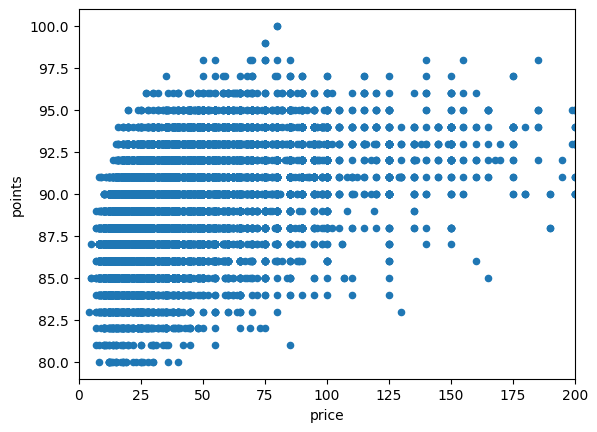

In [ ]:
df.plot.scatter('price', 'points')
plt.xlim(0, 200)

In [ ]:
# What other categorical variable could we One Hot Encode?
df.nunique()

,0
country,1
description,20491
designation,9515
points,21
price,146
province,4
region_1,171
region_2,17
taster_name,11
taster_twitter_handle,11


In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
X_region_ohe = ohe.fit_transform(df[['region_2']]) # Add other columns here

In [ ]:
# Concatenate both Price and OHE columns
X_num = np.hstack([df[['points']].values, X_region_ohe])
pd.DataFrame(X_num)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,87.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,87.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,86.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22382,91.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22383,91.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22384,90.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22385,90.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Scale everything
from sklearn.preprocessing import StandardScaler
X_num = StandardScaler().fit_transform(X_num)
print(X_num.shape)
pd.DataFrame(X_num).head()

(22387, 18)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,-0.903379,-0.165381,-0.514728,-0.165095,-0.572897,-0.062099,-0.050077,-0.307155,-0.132107,-0.022172,-0.111725,-0.13488,-0.205134,-0.419860,-0.087992,-0.148966,-0.119078,2.756893
1,-0.903379,-0.165381,-0.514728,-0.165095,-0.572897,-0.062099,-0.050077,3.255685,-0.132107,-0.022172,-0.111725,-0.13488,-0.205134,-0.419860,-0.087992,-0.148966,-0.119078,-0.362727
2,-0.903379,-0.165381,1.942773,-0.165095,-0.572897,-0.062099,-0.050077,-0.307155,-0.132107,-0.022172,-0.111725,-0.13488,-0.205134,-0.419860,-0.087992,-0.148966,-0.119078,-0.362727
3,-0.903379,-0.165381,-0.514728,-0.165095,-0.572897,-0.062099,-0.050077,-0.307155,-0.132107,-0.022172,-0.111725,-0.13488,-0.205134,2.381749,-0.087992,-0.148966,-0.119078,-0.362727
4,-1.259347,-0.165381,-0.514728,-0.165095,-0.572897,-0.062099,-0.050077,-0.307155,-0.132107,-0.022172,-0.111725,-0.13488,-0.205134,-0.419860,-0.087992,-0.148966,-0.119078,2.756893


In [ ]:
# Define the model inputs, layers and outputs
inputs_num = Input(shape=(X_num.shape[1],))
x = layers.Dense(64, activation="relu")(inputs_num)
x = layers.Dense(32, activation="relu")(x)
outputs_num = layers.Dense(1, activation="relu")(x)

# Define the model
model_num = Model(inputs=inputs_num, outputs=outputs_num)

model_num.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 18)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           1,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
es = EarlyStopping(patience=2)

model_num.compile(loss = "mse", optimizer=Adam(learning_rate=5e-4), metrics=['mae'])
model_num.fit(X_num, y,
          validation_split=0.3,
          epochs=50,
          batch_size=32,
          callbacks=[es]
          )

Epoch 1/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1673.2012 - mae: 31.2888 - val_loss: 1030.6722 - val_mae: 14.2556
Epoch 2/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 511.5099 - mae: 13.8666 - val_loss: 1009.9187 - val_mae: 13.9627
Epoch 3/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 540.9333 - mae: 13.6732 - val_loss: 1005.7896 - val_mae: 13.9173
Epoch 4/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 468.5255 - mae: 13.5430 - val_loss: 1000.9228 - val_mae: 13.8497
Epoch 5/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 434.3496 - mae: 13.2323 - val_loss: 995.5833 - val_mae: 14.0494
Epoch 6/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 421.1717 - mae: 13.3405 - val_loss: 993.8954 - val_mae: 13.8979
Epoch 7/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 415.9349 - mae: 13.3026 - val_loss: 994.0104 - val_mae: 14.0239
Epoch 8/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 439.8378 - mae: 13.4684 - val_loss: 993.2393 - val_mae: 13.8941
Epo

# 4. Combined RNN + Tabular data Inputs !

Let's create a model combining the RNN and the Tabular data model.

This is why we used the functional API before: it allows us to create more advanced model structures. This combined model is no longer a Sequential model!

When we created the two models, we created both inputs, and outputs. We can now concatenate them, and add a small Dense network on top of them.

In [ ]:
# Combine the inputs
inputs = [inputs_nlp, inputs_num]

# Combine the outputs
combined = layers.concatenate([outputs_nlp, outputs_num])

# Add two Dense layers
x = layers.Dense(10, activation="relu")(combined)
outputs = layers.Dense(1, activation="linear")(x)

# And create the model
model_combined = Model(inputs=inputs, outputs=outputs)

In [ ]:
model_combined.summary() #🤮

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 60)             │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, 60, 40)         │        643,040 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 60, 10)         │          6,010 │ embedding[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 60, 10)         │          1,010 │ conv1d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 600)            │              0 │ conv1d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 18)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 30)             │         18,030 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 64)             │          1,216 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 30)             │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 32)             │          2,080 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 1)              │             31 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 1)              │             33 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 2)              │              0 │ dense_1[0][0],         │
│                           │                        │                │ dense_4[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 10)             │             30 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 1)              │             11 │ dense_5[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 671,491 (2.56 MB)

 Trainable params: 671,491 (2.56 MB)

 Non-trainable params: 0 (0.00 B)

😎 Better summary

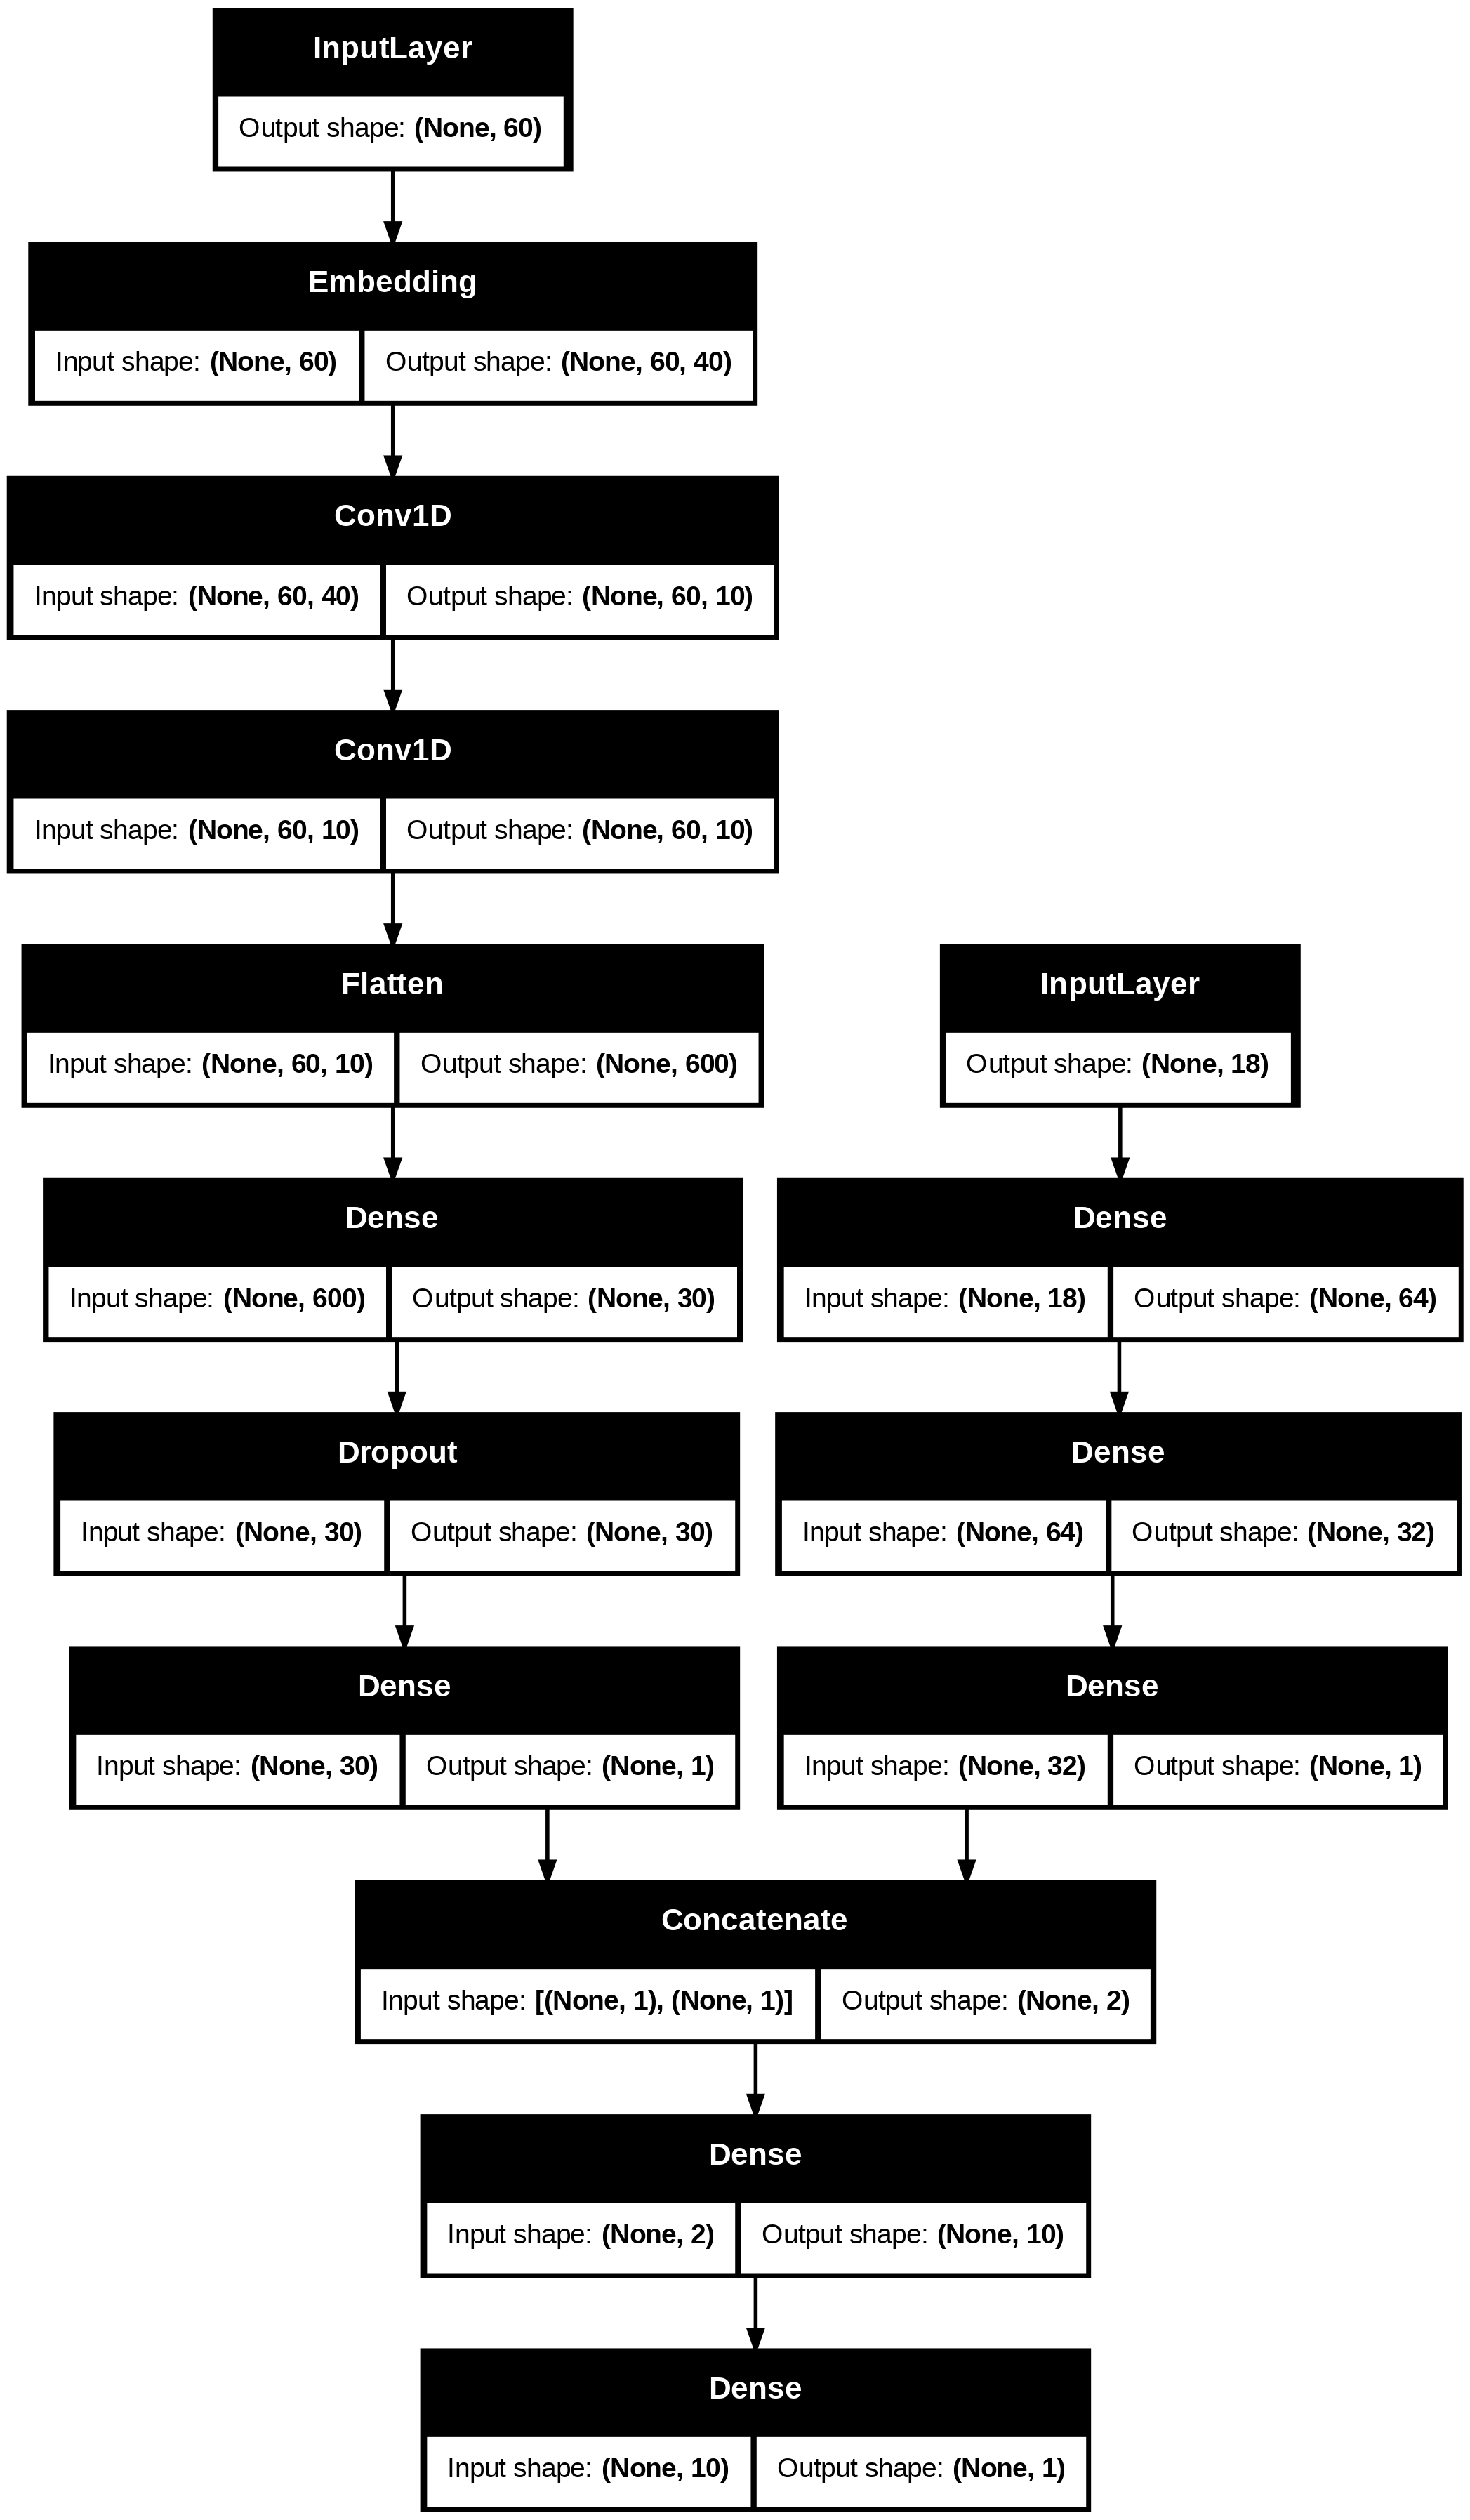

In [ ]:
import tensorflow as tf
tf.keras.utils.plot_model(model_combined, "multi_input_model.png", show_shapes=True)

Now, we can combine and fit it!

Pay attention to the `X` data: it should contain both the text and numeric inputs.

In [ ]:
model_combined.compile(loss="mse", optimizer=Adam(learning_rate=1e-4), metrics=['mae'])
es = EarlyStopping(patience=2)

model_combined.fit(x=[X_pad, X_num],
                   y=y,
                   validation_split=0.3,
                   epochs=100,
                   batch_size=32,
                   callbacks=[es])

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


490/490 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - loss: 299.1052 - mae: 11.2592 - val_loss: 956.5699 - val_mae: 12.8095
Epoch 2/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 259.4031 - mae: 10.3830 - val_loss: 960.8640 - val_mae: 13.1673
Epoch 3/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 249.1740 - mae: 10.1907 - val_loss: 962.7740 - val_mae: 12.9938


**While it's training, let's look at what happens. Do you see how the training starts off with quite a good MAE?**

We didn't re-initialize the outputs: we reused the ones from before, and those have already been trained in the separate models. Because we only compiled and fit, training starts from the weights that have already been learned from the two submodels.

You can think about each stream / branch as an input source of data. And there are many use-cases where you can encounter such type of data?

# 5. Any example of where you might have such data?


- Medical data: ECG, EEG, MRI, PET, cognitive assessments, biomarkers, ...

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/DL/medical_data.png" width='70%'>

- Object detection, in autonomous car for instance where you take a decision based on many sensors (multiple cameras, radars, speed, map, ...

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/DL/autonomous_vehicle.png" width='70%'>
